<a href="https://colab.research.google.com/github/JosegregTovar/GOOGLE-COLLAB/blob/main/Actividad9RLog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 9**
Regresión Logística

---

### **Integrantes:**

*   NOMBRE: JOSEGREG DE JESUS TOVAR BLANCO
*   MATRÍCULA: A01840476
* NOMBRE: Adrian Valdes Zavala
* MATRÍCULA: A01720439
* NOMBRE: Oscar Alfonso Valenzuela Muñoz
* MATRICULA: A01840486
* NOMBRE: Sebastian Valencia Aguirre
* MATRICULA: A01364876


En esta actividad trabajarás con el archivo `breast_cancer.csv`, basado en un conjunto de datos sobre características de tumores mamarios, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar si un tumor es maligno (M) o benigno (B) a partir de medidas extraídas de imágenes de biopsias. Las variables incluidas describen propiedades morfológicas y de textura del tumor y se presentan en tres tipos de medida para cada característica:

* `_mean`: valor promedio de la característica en el tumor
* `_se`: error estándar de la característica (variabilidad de la medición)
* `_worst`: peor valor observado de la característica en el tumor

Los indicadores incluidos son:
* `radius_mean` / `radius_se` / `radius_worst`:	Radio del tumor
* `texture_mean` / `texture_se` / `texture_worst`:	Textura del tumor (desviación estándar de intensidad)
* `perimeter_mean` / `perimeter_se` / `perimeter_worst`:	Perímetro del tumor
* `area_mean` / `area_se` / `area_worst`:	Área del tumor
* `smoothness_mean` / `smoothness_se` / `smoothness_worst`:	Suavidad (irregularidad del borde)
* `compactness_mean` / `compactness_se` / `compactness_worst`:	Compacidad (perimeter^2 / area - 1)
* `concavity_mean` / `concavity_se` / `concavity_worst`:	Concavidad de los contornos
* `concave points_mean` / `concave points_se` / `concave points_worst`:	Número de puntos cóncavos en el contorno
* `symmetry_mean` / `symmetry_se` / `symmetry_worst`:	Simetría del tumor
* `fractal_dimension_mean` / `fractal_dimension_se` / `fractal_dimension_worst`:	Dimensión fractal del contorno (complejidad)
* `diagnosis`: Indica si el tumor es benigno (B) o maligno (M). Es la variable de salida o *target*

In [1]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


"Paleta de colores 'PuRd' cargada correctamente."

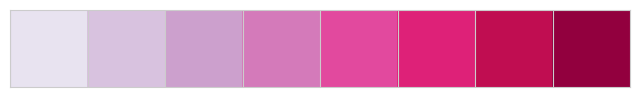

In [3]:

# Estilo visual profesional

sns.set_style("whitegrid")

# Paleta de colores solicitada
paleta_colores = sns.color_palette("PuRd", 8)

sns.set_palette(paleta_colores)

# Tamaño estándar de figuras
plt.rcParams["figure.figsize"] = (10,6)

# Mostrar la paleta para confirmar
sns.palplot(paleta_colores)

display("Paleta de colores 'PuRd' cargada correctamente.")

In [4]:
# Leer el archivo CSV
cancer_df = pd.read_csv("/content/drive/MyDrive/01 Analisis de Datos/ACTIVIDAD 9/breast_cancer.csv")

# Mostrar las primeras filas para verificar que cargó correctamente
display(cancer_df.head())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


1. Descarga el archivo: `breast_cancer.csv` y guarda, en un dataframe (`cancer_df`), todos sus registros.
* Haz que la columna `id` sea el nuevo índice.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Verifica si alguna columna contiene valores faltantes.
* Si existen registros duplicados, elimínalos del dataframe y reinicia el índice para que se mantenga consecutivo.
* Obtén las estadísticas descriptivas, separando las variables numéricas (con asimetría y curtosis) y las categóricas.

In [5]:
# CONVERTIR ID EN ÍNDICE


cancer_df = cancer_df.set_index("id")

display(cancer_df.head())

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
# RESUMEN DEL DATASET

display(cancer_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                 

None

In [7]:
# CONTEO DE TIPOS DE VARIABLES

# Columnas numéricas
columnas_numericas = cancer_df.select_dtypes(include=["float64","int64"]).columns

# Columnas de texto
columnas_texto = cancer_df.select_dtypes(include=["object"]).columns

# Resultados
display("Número de columnas numéricas:", len(columnas_numericas))
display("Número de columnas de texto:", len(columnas_texto))

display("Columnas de texto:")
display(columnas_texto)

'Número de columnas numéricas:'

30

'Número de columnas de texto:'

1

'Columnas de texto:'

Index(['diagnosis'], dtype='object')

In [8]:

# VERIFICACIÓN DE VALORES FALTANTES

# Conteo de valores faltantes por columna
valores_faltantes = cancer_df.isnull().sum()

# Filtrar solo columnas con faltantes
faltantes_por_columna = valores_faltantes[valores_faltantes > 0]

display("Conteo de valores faltantes por columna:")
display(valores_faltantes)

display("Columnas con valores faltantes:")
display(faltantes_por_columna)

# Total general de valores faltantes
total_faltantes = cancer_df.isnull().sum().sum()

display(f"Total de valores faltantes en el dataframe: {total_faltantes}")

'Conteo de valores faltantes por columna:'

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


'Columnas con valores faltantes:'

,0


'Total de valores faltantes en el dataframe: 0'

In [9]:
# DETECCIÓN Y ELIMINACIÓN DE DUPLICADOS

# Cantidad de registros duplicados
duplicados_antes = cancer_df.duplicated().sum()

display(f"Cantidad de registros duplicados antes de limpiar: {duplicados_antes}")

# Eliminar duplicados
cancer_df = cancer_df.drop_duplicates()

# Reiniciar índice para dejarlo consecutivo
cancer_df = cancer_df.reset_index(drop=True)

# Confirmación posterior
duplicados_despues = cancer_df.duplicated().sum()

display(f"Cantidad de registros duplicados después de limpiar: {duplicados_despues}")
display("Vista previa del dataframe con índice reiniciado:")
display(cancer_df.head())

'Cantidad de registros duplicados antes de limpiar: 0'

'Cantidad de registros duplicados después de limpiar: 0'

'Vista previa del dataframe con índice reiniciado:'

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [10]:

# ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMÉRICAS

# Seleccionar variables numéricas
variables_numericas = cancer_df.select_dtypes(include=["int64", "float64"])

# Estadísticas descriptivas básicas
resumen_numerico = variables_numericas.describe().T

# Agregar asimetría y curtosis
resumen_numerico["asimetria"] = variables_numericas.skew()
resumen_numerico["curtosis"] = variables_numericas.kurt()

display("Resumen descriptivo de variables numéricas:")
display(resumen_numerico)

'Resumen descriptivo de variables numéricas:'

,count,mean,std,min,25%,50%,75%,max,asimetria,curtosis
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000,0.942380,0.845522
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000,0.650450,0.758319
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000,0.990650,0.972214
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000,1.645732,3.652303
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340,0.456324,0.855975
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540,1.190123,1.650130
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680,1.401180,1.998638
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120,1.171180,1.066556
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400,0.725609,1.287933
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744,1.304489,3.005892


In [11]:
# ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES CATEGÓRICAS


# Seleccionar variables categóricas
variables_categoricas = cancer_df.select_dtypes(include=["object"])

# Resumen descriptivo categórico
resumen_categorico = variables_categoricas.describe().T

display("Resumen descriptivo de variables categóricas:")
display(resumen_categorico)

'Resumen descriptivo de variables categóricas:'

,count,unique,top,freq
diagnosis,569,2,B,357


2. Explora relaciones bivariadas en el conjunto de datos mediante gráficos:
* Calcula y visualiza la distribución porcentual de la variable `diagnosis` usando un gráfico de barras, mostrando el porcentaje encima de cada barra. ¿Por qué la distribución de la salida es relevante en un problema de clasificación?
* Genera un pairplot de las variables físicas del conjunto _mean (`radius_mean`, `perimeter_mean`, `area_mean`, `texture_mean`) coloreando por la variable `diagnosis`. ¿Qué relaciones observas entre las variables físicas? ¿Qué diferencias hay entre los tumores benignos y malignos?
* Crea histogramas apilados de las variables morfológicas (`smoothness_mean`, `compactness_mean`, `concavity_mean`, `concave points_mean`, `symmetry_mean`, `fractal_dimension_mean`) coloreando por `diagnosis` para explorar la distribución de cada variable según el tipo de tumor. ¿Alguna variable parece ser un buen discriminador entre las clases?

## ***2.1***

'Conteo de casos por diagnóstico'

,count
diagnosis,
B,357
M,212


'Porcentaje de casos por diagnóstico'

,proportion
diagnosis,
B,62.741652
M,37.258348


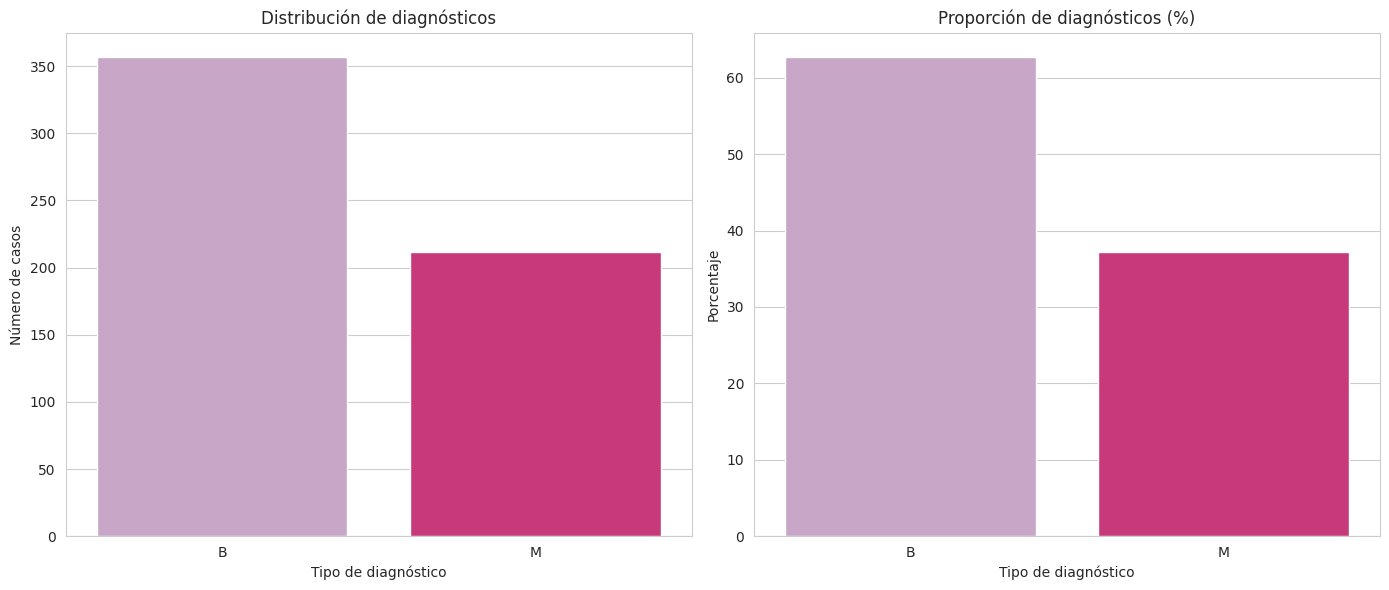

In [12]:
# Conteo de diagnósticos
conteo_diagnostico = cancer_df["diagnosis"].value_counts()

display("Conteo de casos por diagnóstico")
display(conteo_diagnostico)


# Cálculo de porcentajes
porcentaje_diagnostico = cancer_df["diagnosis"].value_counts(normalize=True) * 100

display("Porcentaje de casos por diagnóstico")
display(porcentaje_diagnostico)


# Definir orden fijo de las categorías
orden_diagnostico = ["B", "M"]


# Crear figura con subplots
fig, axes = plt.subplots(1, 2, figsize=(14,6))


# Gráfico de conteo
sns.countplot(
    data=cancer_df,
    x="diagnosis",
    hue="diagnosis",
    order=orden_diagnostico,
    hue_order=orden_diagnostico,
    palette="PuRd",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Distribución de diagnósticos")
axes[0].set_xlabel("Tipo de diagnóstico")
axes[0].set_ylabel("Número de casos")


# Preparar dataframe de porcentajes
df_porcentaje = porcentaje_diagnostico.reset_index()
df_porcentaje.columns = ["diagnosis", "porcentaje"]


# Gráfico de porcentajes
sns.barplot(
    data=df_porcentaje,
    x="diagnosis",
    y="porcentaje",
    hue="diagnosis",
    order=orden_diagnostico,
    hue_order=orden_diagnostico,
    palette="PuRd",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Proporción de diagnósticos (%)")
axes[1].set_xlabel("Tipo de diagnóstico")
axes[1].set_ylabel("Porcentaje")


plt.tight_layout()

display(fig)

plt.close()

*¿Por qué la distribución de la salida es relevante en un problema de clasificación?*

**Respuesta:**

La distribución de la variable de salida es un aspecto fundamental en problemas de clasificación porque determina cómo están representadas las clases dentro del conjunto de datos. Cuando las clases están equilibradas, el modelo tiene suficientes ejemplos de cada categoría para aprender los patrones que las distinguen.

Sin embargo, cuando existe un desbalance significativo entre clases, el modelo puede sesgarse hacia la clase mayoritaria. En ese caso, el modelo podría obtener una alta exactitud simplemente prediciendo siempre la clase más frecuente, sin realmente aprender las características que diferencian las clases.

En problemas médicos como el diagnóstico de cáncer, este aspecto es importantisimo ya que un modelo que favorezca la clase mayoritaria podría fallar al detectar casos malignos, lo cual tendría consecuencias graves. Por esta razón, analizar la distribución de la variable objetivo al inicio del análisis exploratorio permite identificar posibles desbalances y considerar técnicas de ajuste si fuera necesario durante el modelado.

## ***2.2***

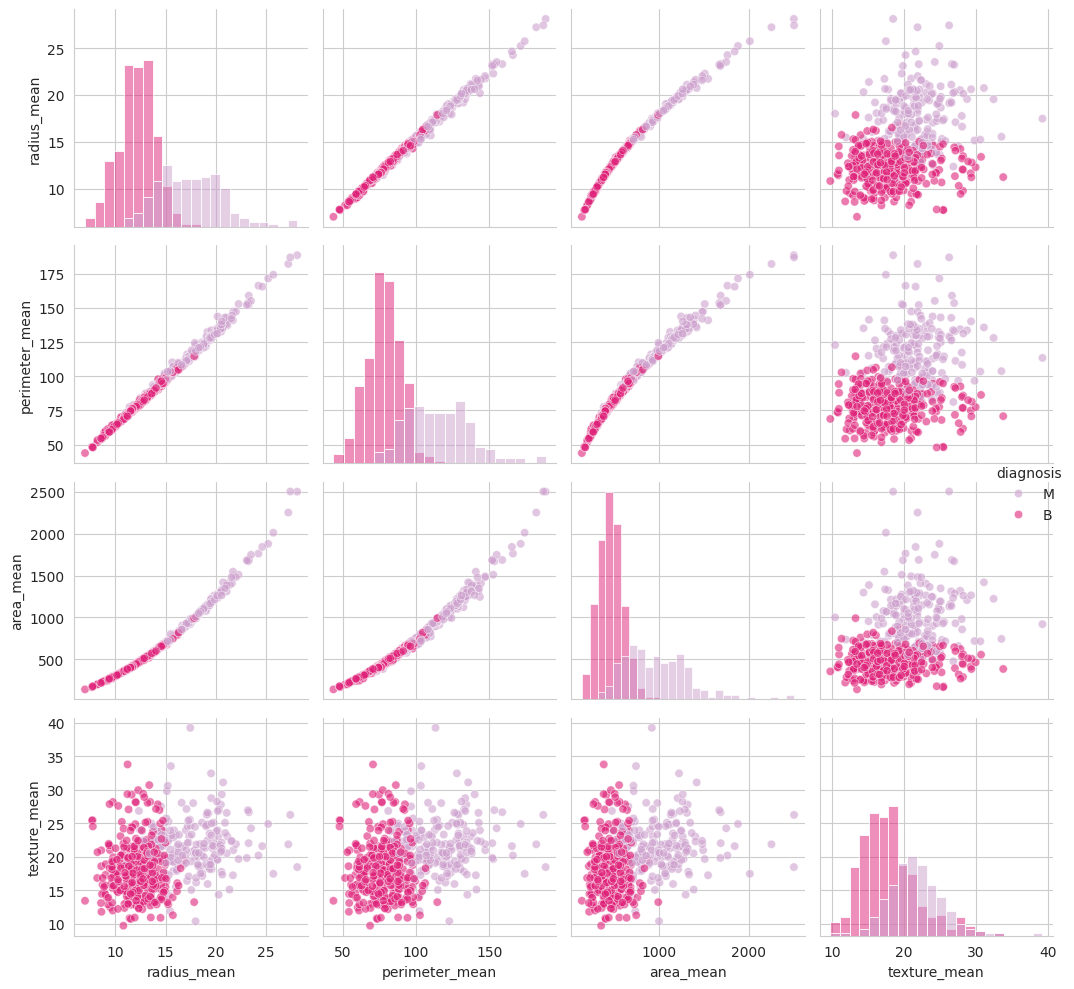

In [13]:
# Selección de variables físicas
variables_fisicas = [
    "radius_mean",
    "perimeter_mean",
    "area_mean",
    "texture_mean",
    "diagnosis"
]

df_fisicas = cancer_df[variables_fisicas]


pairplot_fisicas = sns.pairplot(
    data=df_fisicas,
    hue="diagnosis",
    palette="PuRd",
    corner=False,
    diag_kind="hist",
    plot_kws={"alpha":0.6}
)

pairplot_fisicas.fig.tight_layout()

display(pairplot_fisicas.fig)

plt.close()

**Análisis del pairplot de variables físicas**

El pairplot permite observar la relación entre las variables físicas `radius_mean`, `perimeter_mean`, `area_mean` y `texture_mean`, diferenciando los puntos según el diagnóstico del tumor.

Se aprecia una relación positiva muy fuerte entre `radius_mean`, `perimeter_mean` y `area_mean` Esto tiene sentido porque las tres variables están asociadas al tamaño del tumor, por lo que cuando una aumenta las otras también tienden a incrementarse.

En cuanto a la separacion entre clases, los tumores malignos suelen concentrarse en valores más altos de radio, perímetro y área, mientras que los tumores benignos tienden a ubicarse en rangos más bajos. Esto sugiere que las variables relacionadas con el tamaño tienen un importante poder discriminatorio.

Por otro lado, `texture_mean` muestra mayor superposición entre ambas clases, por lo que visualmente parece aportar menos capacidad de separación que las variables de tamaño.

En conjunto, el gráfico sugiere que las características físicas asociadas al tamaño del tumor son mas relevantes para distinguir entre tumores benignos y malignos.

## ***2.3***

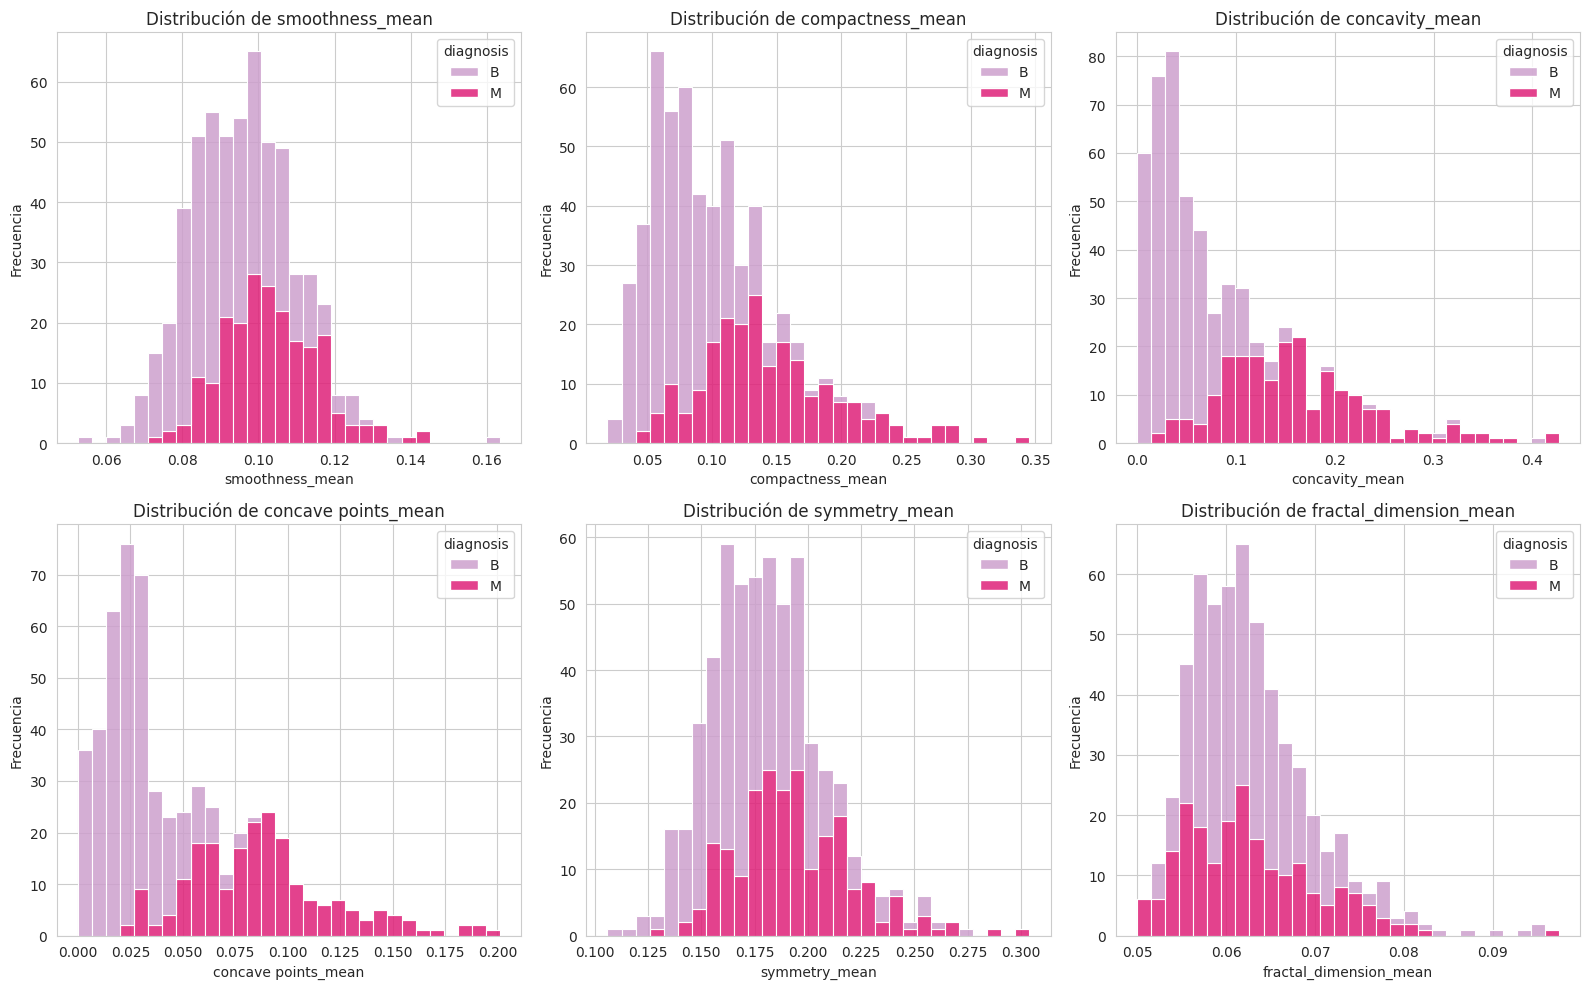

In [14]:
# Variables morfológicas
variables_morfologicas = [
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave points_mean",
    "symmetry_mean",
    "fractal_dimension_mean"
]


# Crear copia de trabajo
df_morfologicas = cancer_df[variables_morfologicas + ["diagnosis"]].copy()


# Fijar orden de clases para mantener colores consistentes
df_morfologicas["diagnosis"] = pd.Categorical(
    df_morfologicas["diagnosis"],
    categories=["B", "M"],
    ordered=True
)


# Crear figura con subplots
fig, axes = plt.subplots(2, 3, figsize=(16,10))

axes = axes.flatten()


# Generar histogramas
for i, variable in enumerate(variables_morfologicas):

    sns.histplot(
        data=df_morfologicas,
        x=variable,
        hue="diagnosis",
        hue_order=["B","M"],
        palette=sns.color_palette("PuRd",2),
        multiple="stack",
        bins=30,
        alpha=0.85,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribución de {variable}")
    axes[i].set_xlabel(variable)
    axes[i].set_ylabel("Frecuencia")


plt.tight_layout()

display(fig)

plt.close()

**Distribución de variables morfológicas según el diagnóstico**

Se observa que variables como `concavity_mean` y `concave points_mean` presentan una diferencia más clara entre tumores benignos y malignos. Los tumores malignos tienden a concentrarse en valores más altos de estas variables, lo que sugiere una mayor irregularidad en la forma del tumor.

Por otro lado, variables como `symmetry_mean` y `fractal_dimension_mean` muestran una mayor superposición entre las distribuciones de ambas clases, lo que indica que su capacidad para discriminar entre tumores benignos y malignos podría ser menor cuando se analizan de forma individual.

En general, las variables relacionadas con la concavidad y los puntos cóncavos parecen ser indicadores más útiles para diferenciar entre tumores benignos y malignos, lo cual resulta consistente con estudios previos sobre caracteristicas asociadas a tumores malignos

3. Antes de realizar el análisis de correlación, crea una copia del dataframe (`cancer_copy`).
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos. La alta correlación entre las variables del conjunto _mean y _worst es inevitable, ya que las columnas _worst representan esencialmente los valores máximos de las mismas características medidas en _mean. Elimina las columnas _worst para simplificar el análisis.
* Imprime nuevamente los pares con correlación superior a 0.9. Como habías observado previamente, existen relaciones lineales entre `radius`, `perimeter` y `area`, por lo que era esperable encontrar altas correlaciones. De estas tres medidas, ¿cuál mantendrías y por qué? Elimina todas las variables de los otros dos conjuntos.
* Dibuja un mapa de calor con la matriz de correlación para identificar si prevalece alguna correlación relevante. Si eliminas alguna otra variable, justifica tu elección.

In [15]:
# Crear copia del dataframe original
cancer_copy = cancer_df.copy()

display("Dimensiones del dataframe original")
display(cancer_df.shape)

display("Dimensiones de la copia de trabajo")
display(cancer_copy.shape)

'Dimensiones del dataframe original'

(569, 31)

'Dimensiones de la copia de trabajo'

(569, 31)

## ***3.1***

In [16]:
# Crear matriz de correlación
matriz_correlacion = cancer_copy.corr(numeric_only=True)


# Extraer pares de correlaciones altas
pares_altos = []

for i in range(len(matriz_correlacion.columns)):
    for j in range(i):

        if abs(matriz_correlacion.iloc[i, j]) > 0.9:

            columna1 = matriz_correlacion.columns[i]
            columna2 = matriz_correlacion.columns[j]
            valor_corr = matriz_correlacion.iloc[i, j]

            pares_altos.append((columna1, columna2, valor_corr))


# Convertir a dataframe para visualizar mejor
df_correlaciones_altas = pd.DataFrame(
    pares_altos,
    columns=["Variable 1", "Variable 2", "Correlación"]
)

display("Pares de variables con correlación superior a 0.9")
display(df_correlaciones_altas)

'Pares de variables con correlación superior a 0.9'

,Variable 1,Variable 2,Correlación
0,perimeter_mean,radius_mean,0.997855
1,area_mean,radius_mean,0.987357
2,area_mean,perimeter_mean,0.986507
3,concave points_mean,concavity_mean,0.921391
4,perimeter_se,radius_se,0.972794
5,area_se,radius_se,0.951830
6,area_se,perimeter_se,0.937655
7,radius_worst,radius_mean,0.969539
8,radius_worst,perimeter_mean,0.969476
9,radius_worst,area_mean,0.962746


In [17]:
# Identificar columnas _worst
columnas_worst = [col for col in cancer_copy.columns if "_worst" in col]

display("Columnas eliminadas (_worst)")
display(columnas_worst)

# Eliminar columnas
cancer_copy = cancer_copy.drop(columns=columnas_worst)

display("Dimensiones del dataset después de eliminar _worst")
display(cancer_copy.shape)

'Columnas eliminadas (_worst)'

['radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst']

'Dimensiones del dataset después de eliminar _worst'

(569, 21)

## **3.2**

In [18]:
# Nueva matriz de correlación
matriz_correlacion = cancer_copy.corr(numeric_only=True)

pares_altos = []

for i in range(len(matriz_correlacion.columns)):
    for j in range(i):

        if abs(matriz_correlacion.iloc[i, j]) > 0.9:

            columna1 = matriz_correlacion.columns[i]
            columna2 = matriz_correlacion.columns[j]
            valor_corr = matriz_correlacion.iloc[i, j]

            pares_altos.append((columna1, columna2, valor_corr))


df_correlaciones_altas = pd.DataFrame(
    pares_altos,
    columns=["Variable 1", "Variable 2", "Correlación"]
)

display("Pares con correlación superior a 0.9 después de eliminar _worst")
display(df_correlaciones_altas)

'Pares con correlación superior a 0.9 después de eliminar _worst'

,Variable 1,Variable 2,Correlación
0,perimeter_mean,radius_mean,0.997855
1,area_mean,radius_mean,0.987357
2,area_mean,perimeter_mean,0.986507
3,concave points_mean,concavity_mean,0.921391
4,perimeter_se,radius_se,0.972794
5,area_se,radius_se,0.951830
6,area_se,perimeter_se,0.937655


In [19]:
# Variables eliminadas por alta correlación
variables_eliminar = [
    "perimeter_mean",
    "area_mean",
    "perimeter_se",
    "area_se"
]

display("Variables eliminadas por alta correlación")
display(variables_eliminar)

cancer_copy = cancer_copy.drop(columns=variables_eliminar)

display("Dimensiones del dataset después de eliminar variables correlacionadas")
display(cancer_copy.shape)

'Variables eliminadas por alta correlación'

['perimeter_mean', 'area_mean', 'perimeter_se', 'area_se']

'Dimensiones del dataset después de eliminar variables correlacionadas'

(569, 17)

**Explicación:**

Lo más lógico es desaparecer perimetro y área que al final son funciones que dependen directamente del radio.

## **3.3**

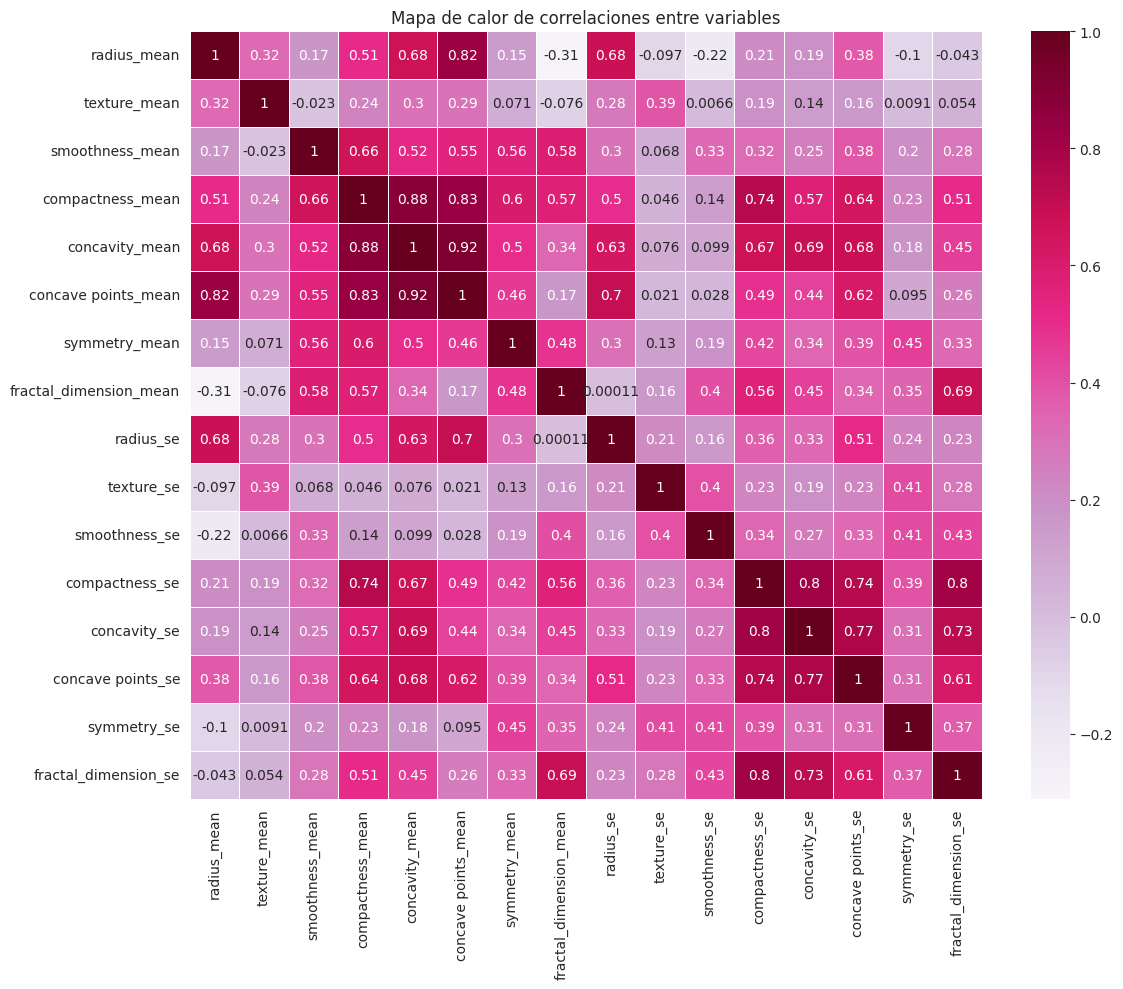

In [20]:
# Matriz de correlación final
matriz_correlacion = cancer_copy.corr(numeric_only=True)


fig, ax = plt.subplots(figsize=(12,10))

sns.heatmap(
    matriz_correlacion,
    cmap="PuRd",
    annot=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Mapa de calor de correlaciones entre variables")

plt.tight_layout()

display(fig)

plt.close()

In [21]:
# Eliminar la variable concavity_mean del dataframe de trabajo
cancer_copy = cancer_copy.drop(columns=["concavity_mean"])

display("Variable eliminada:")
display("concavity_mean")

display("Dimensiones actuales del dataframe:")
display(cancer_copy.shape)

'Variable eliminada:'

'concavity_mean'

'Dimensiones actuales del dataframe:'

(569, 16)

In [22]:
display("Columnas actuales del dataframe:")
display(cancer_copy.columns)

'Columnas actuales del dataframe:'

Index(['diagnosis', 'radius_mean', 'texture_mean', 'smoothness_mean',
       'compactness_mean', 'concave points_mean', 'symmetry_mean',
       'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se'],
      dtype='object')

### Análisis de correlación entre variables

El análisis de correlación permitió identificar múltiples pares de variables con valores superiores a 0.9, lo cual indica una fuerte relación lineal entre ellas. En particular, las variables del grupo `_worst` mostraban una alta correlación con sus equivalentes del grupo `_mean`, lo cual era esperable ya que representan valores máximos de las mismas características. Por esta razón se decidió eliminar las columnas `_worst` para simplificar el modelo y evitar redundancia en la información.

Posteriormente, se observó que las variables `radius_mean`, `perimeter_mean` y `area_mean` presentan relaciones lineales muy fuertes. Esto es debido a su formula geométrica de estas medidas ya que el perímetro y el área dependen directamente del radio del tumor. Para reducir la multicolinealidad, se decidió conservar únicamente `radius_mean`, eliminando `perimeter_mean` y `area_mean`.

El mapa de calor de la matriz de correlación permite visualizar las relaciones restantes entre variables. Se observó una correlación muy alta entre `concavity_mean` y `concave points_mean` (0.92), lo que indica que ambas variables capturan información muy similar sobre la irregularidad del borde del tumor.

Para decidir cuál conservar se analizaron estadísticas descriptivas y su capacidad de discriminación. La variable `concavity_mean` presenta mayor asimetría y curtosis, lo que indica una distribución más extrema y potencialmente menos estable para modelos lineales.

Por otro lado, `concave points_mean` tiende a mostrar una relación más directa con la complejidad del borde tumoral y suele presentar mayor correlación con la variable objetivo en este dataset.

Por estas razones se decidió conservar `concave points_mean` y eliminar `concavity_mean`, reduciendo así la multicolinealidad sin perder capacidad predictiva relevante.

Se observó una correlación muy alta entre `concavity_mean` y `concave points_mean` (0.92), lo que indica que ambas variables capturan información muy similar sobre la irregularidad del borde del tumor.

Para decidir cuál conservar se analizaron estadísticas descriptivas y su capacidad de discriminación. La variable `concavity_mean` presenta mayor asimetría y curtosis, lo que indica una distribución más extrema y potencialmente menos estable para modelos lineales.

Por otro lado, `concave points_mean` investigando un poco encontré que tiende a mostrar una relación más directa con la complejidad del borde tumoral y suele presentar mayor correlación con la variable objetivo en este dataset.

Por estas razones se decidió conservar `concave points_mean` y eliminar `concavity_mean`, reduciendo así la multicolinealidad.

4. Separa las variables predictoras `X` de la variable de salida `y`, usando el dataframe original `cancer_df` (la eliminación de variables correlacionadas se integrará en el pipeline).
* Codifica `diagnosis` como 0 (Benigno) y 1 (Maligno).
* Divide el conjunto de datos en entrenamiento y prueba (80:20), usando `random_state=1` para garantizar reproducibilidad.
* Para evaluar los modelos que se construirán, define una función llamada `evaluate_model` que reciba los valores reales y las predicciones e imprima las métricas de recall, precisión y exactitud (accuracy).

In [23]:
# Separar variables predictoras y variable objetivo

X = cancer_df.drop(columns=["diagnosis"])
y = cancer_df["diagnosis"]

display("Dimensiones de X (variables predictoras):")
display(X.shape)

display("Dimensiones de y (variable objetivo):")
display(y.shape)

'Dimensiones de X (variables predictoras):'

(569, 30)

'Dimensiones de y (variable objetivo):'

(569,)

In [24]:
# Codificar variable objetivo

y = y.map({
    "B": 0,
    "M": 1
})

display("Distribución de la variable objetivo codificada:")
display(y.value_counts())

'Distribución de la variable objetivo codificada:'

,count
diagnosis,
0,357
1,212


In [25]:

# División del dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1
)

display("Dimensiones del conjunto de entrenamiento:")
display(X_train.shape)

display("Dimensiones del conjunto de prueba:")
display(X_test.shape)

'Dimensiones del conjunto de entrenamiento:'

(455, 30)

'Dimensiones del conjunto de prueba:'

(114, 30)

In [26]:
#Creación de la función


def evaluate_model(y_real, y_pred):

    accuracy = accuracy_score(y_real, y_pred)
    precision = precision_score(y_real, y_pred)
    recall = recall_score(y_real, y_pred)

    display("Métricas del modelo")

    display(f"Accuracy: {accuracy:.3f}")
    display(f"Precision: {precision:.3f}")
    display(f"Recall: {recall:.3f}")

5. Prepara un transformador denominado `preprocessing`, usando ColumnTransformer, para borrar las columnas altamente correlacionadas (identificadas en el ejercicio 3) Asegúrate de incluir el parámetro `remainder='passthrough'` para mantener el resto de las variables.
* Crea un pipeline que integre el transformador y regresión logística para  entrenar un modelo.
* Evalúa el desempeño del modelo en el conjunto de prueba empleando la función `evaluate_model`.
* Integra los resultados en un dataframe que contenga el nombre del modelo (*Correlation_Clean*) y una columna para cada métrica calculada.

In [27]:
#Columnas correlacionadas
columnas_corre = [
    "perimeter_mean",
    "area_mean",
    "perimeter_se",
    "area_se",
    "concavity_mean"
]

# columnas altamente correlacionadas a eliminar
columnas_eliminar =  columnas_corre+ columnas_worst

# transformador de preprocesamiento
preprocessing = ColumnTransformer(
    transformers=[
        ("eliminar_correlacionadas", "drop", columnas_eliminar)
    ],
    remainder="passthrough",
    force_int_remainder_cols=False
)


In [28]:
# Creacion del Codigo Pipeline

pipeline_correlacion = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("modelo", LogisticRegression(max_iter=1000))
    ]
)

display("Pipeline creado:")
display(pipeline_correlacion)
#

'Pipeline creado:'

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('eliminar_correlacionadas',
                                                  'drop',
                                                  ['perimeter_mean',
                                                   'area_mean', 'perimeter_se',
                                                   'area_se', 'concavity_mean',
                                                   'radius_worst',
                                                   'texture_worst',
                                                   'perimeter_worst',
                                                   'area_worst',
                                                   'smoothness_worst',
                                                   'compactness_worst',
                                                   'concavity_worst',
                                                   'concave points_worst',
                                                   'symmetry_worst',
                                                   'fractal_dimension_worst'])])),
                ('modelo', LogisticRegression(max_iter=1000))])

In [29]:
#Entrenar el Modelo

pipeline_correlacion.fit(X_train, y_train)

display("Modelo entrenado")

'Modelo entrenado'

In [30]:
#Evaluar el modelo

predicciones = pipeline_correlacion.predict(X_test)

evaluate_model(y_test, predicciones)

'Métricas del modelo'

'Accuracy: 0.877'

'Precision: 0.889'

'Recall: 0.762'

In [31]:
#Integrar los resultados

accuracy = accuracy_score(y_test, predicciones)
precision = precision_score(y_test, predicciones)
recall = recall_score(y_test, predicciones)

resultados_modelos = pd.DataFrame({
    "modelo": ["Correlation_Clean"],
    "accuracy": [accuracy],
    "precision": [precision],
    "recall": [recall]
})

display("Resultados del modelo")
display(resultados_modelos)

'Resultados del modelo'

,modelo,accuracy,precision,recall
0,Correlation_Clean,0.877193,0.888889,0.761905


6. Una alternativa para reducir la multicolinealidad es el análisis de componentes principales. Construye un pipeline que incluya escalado estándar, PCA y regresión logística, manteniendo el número mínimo de componentes principales que expliquen al menos el 90% de la varianza.
* Entrena el modelo utilizando el conjunto de entrenamiento y evalúalo en el conjunto de prueba.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Standard_PCA*.
* ¿Cuántos componentes principales se emplearon?

In [32]:
#Creamos el pipeline

pipeline_pca = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.90)),
        ("modelo", LogisticRegression(max_iter=1000, random_state=1))
    ]
)

display("Pipeline PCA creado")
display(pipeline_pca)

'Pipeline PCA creado'

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.9)),
                ('modelo', LogisticRegression(max_iter=1000, random_state=1))])

In [33]:
#Entrenar el modelo y evaluarlo

# entrenar modelo
pipeline_pca.fit(X_train, y_train)

display("Modelo PCA entrenado")


# generar predicciones
predicciones_pca = pipeline_pca.predict(X_test)


# evaluar modelo
evaluate_model(y_test, predicciones_pca)

'Modelo PCA entrenado'

'Métricas del modelo'

'Accuracy: 0.974'

'Precision: 1.000'

'Recall: 0.929'

In [34]:
#Guardar metricas

accuracy_pca = accuracy_score(y_test, predicciones_pca)
precision_pca = precision_score(y_test, predicciones_pca)
recall_pca = recall_score(y_test, predicciones_pca)

#Integrar los resultados.

nuevo_resultado = pd.DataFrame({
    "modelo": ["Standard_PCA"],
    "accuracy": [accuracy_pca],
    "precision": [precision_pca],
    "recall": [recall_pca]
})

resultados_modelos = pd.concat(
    [resultados_modelos, nuevo_resultado],
    ignore_index=True
)

display("Resultados actualizados")
display(resultados_modelos)

'Resultados actualizados'

,modelo,accuracy,precision,recall
0,Correlation_Clean,0.877193,0.888889,0.761905
1,Standard_PCA,0.973684,1.000000,0.928571


In [35]:
num_componentes = pipeline_pca.named_steps["pca"].n_components_

display("Número de componentes principales utilizados:")
display(int(num_componentes))

'Número de componentes principales utilizados:'

7

### Modelo con reducción de dimensionalidad mediante PCA

Como alternativa a la eliminación manual de variables correlacionadas, se implementó un pipeline que incorpora escalado estaadar, análisis de componentes principales (PCA) y regresión logística.

El escalado estándar se aplicó antes del PCA para asegurar que todas las variables contribuyan de manera comparable al cálculo de los componentes principales. Posteriormente, el PCA se configuró para conservar el número mínimo de componentes necesarios para explicar al menos el 90% de la varianza del conjunto de datos, dando resultado 7 componentes.

El modelo fue entrenado utilizando el conjunto de entrenamiento y evaluado en el conjunto de prueba mediante las métricas de exactitud, precisión y recall. Los resultados obtenidos se añadieron al dataframe de comparación de modelos bajo el nombre *Standard_PCA*.

7. Como intento de mejorar las métricas del modelo, y dado que todas las variables presentan sesgo, aplica una normalización utilizando Yeo-Johnson. Para ello:
* Crea un pipeline que integre el transformador `preprocessing`, una transformación Yeo-Johnson y regresión logística.
* Entrena el modelo utilizando el conjunto de entrenamiento y evalúalo en el conjunto de prueba.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Correlation_Yeo*.

In [36]:
# Crear pipeline que incluya:
# preprocessing (elimina variables correlacionadas)
# transformación Yeo-Johnson
# regresión logística

pipeline_yeo = Pipeline(

    steps=[

        # eliminar variables altamente correlacionadas
        ("preprocessing", preprocessing),

        # aplicar transformación Yeo-Johnson
        # esta transformación reduce el sesgo de las variables
        ("yeo_johnson", PowerTransformer(method="yeo-johnson", standardize=True)),

        # modelo de regresión logística
        ("modelo", LogisticRegression(max_iter=1000, random_state=1))

    ]

)

display("Pipeline con transformación Yeo-Johnson creado correctamente")
display(pipeline_yeo)


'Pipeline con transformación Yeo-Johnson creado correctamente'

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('eliminar_correlacionadas',
                                                  'drop',
                                                  ['perimeter_mean',
                                                   'area_mean', 'perimeter_se',
                                                   'area_se', 'concavity_mean',
                                                   'radius_worst',
                                                   'texture_worst',
                                                   'perimeter_worst',
                                                   'area_worst',
                                                   'smoothness_worst',
                                                   'compactness_worst',
                                                   'concavity_worst',
                                                   'concave points_worst',
                                                   'symmetry_worst',
                                                   'fractal_dimension_worst'])])),
                ('yeo_johnson', PowerTransformer()),
                ('modelo', LogisticRegression(max_iter=1000, random_state=1))])

In [37]:
# entrenar modelo
pipeline_yeo.fit(X_train, y_train)

display("Modelo Correlation_Yeo entrenado")


# generar predicciones
predicciones_yeo = pipeline_yeo.predict(X_test)


# evaluar modelo
evaluate_model(y_test, predicciones_yeo)

'Modelo Correlation_Yeo entrenado'

'Métricas del modelo'

'Accuracy: 0.982'

'Precision: 1.000'

'Recall: 0.952'

In [38]:
# calcular métricas

accuracy_yeo = accuracy_score(y_test, predicciones_yeo)
precision_yeo = precision_score(y_test, predicciones_yeo)
recall_yeo = recall_score(y_test, predicciones_yeo)

# crear dataframe con resultados
nuevo_resultado = pd.DataFrame({
    "modelo": ["Correlation_Yeo"],
    "accuracy": [accuracy_yeo],
    "precision": [precision_yeo],
    "recall": [recall_yeo]
})


# añadir resultados al dataframe existente
resultados_modelos = pd.concat(
    [resultados_modelos, nuevo_resultado],
    ignore_index=True
)

display("Resultados actualizados con modelo Correlation_Yeo")
display(resultados_modelos)

'Resultados actualizados con modelo Correlation_Yeo'

,modelo,accuracy,precision,recall
0,Correlation_Clean,0.877193,0.888889,0.761905
1,Standard_PCA,0.973684,1.000000,0.928571
2,Correlation_Yeo,0.982456,1.000000,0.952381


8. Del modelo anterior, obtén los nombres de los predictores empleados. ¿Cuántos son?
* Revisa los coeficientes del modelo de regresión logística y analiza su magnitud para identificar las variables 10 más influyentes.
* Grafícalas en un barplot horizontal, mostrando el valor del coeficiente y respetando su signo.

In [39]:
# obtener nombres de columnas originales
columnas_originales = X.columns


# eliminar columnas correlacionadas
columnas_predictoras = [
    col for col in columnas_originales
    if col not in columnas_eliminar
]

display("Predictores utilizados por el modelo:")
display(columnas_predictoras)

display("Número de predictores utilizados:")
display(len(columnas_predictoras))

'Predictores utilizados por el modelo:'

['radius_mean',
 'texture_mean',
 'smoothness_mean',
 'compactness_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se']

'Número de predictores utilizados:'

15

In [40]:
# obtener coeficientes del modelo entrenado
coeficientes = pipeline_yeo.named_steps["modelo"].coef_[0]


# crear dataframe con variables y coeficientes
coef_df = pd.DataFrame({
    "variable": columnas_predictoras,
    "coeficiente": coeficientes
})


# ordenar por magnitud del coeficiente
coef_df["magnitud"] = coef_df["coeficiente"].abs()

top_variables = coef_df.sort_values(
    by="magnitud",
    ascending=False
).head(10)

display("Variables más influyentes en el modelo")
display(top_variables)

'Variables más influyentes en el modelo'

,variable,coeficiente,magnitud
4,concave points_mean,2.467117,2.467117
1,texture_mean,1.906850,1.906850
0,radius_mean,1.379170,1.379170
7,radius_se,1.320211,1.320211
11,concavity_se,1.012023,1.012023
5,symmetry_mean,0.783896,0.783896
13,symmetry_se,-0.720241,0.720241
10,compactness_se,-0.697009,0.697009
3,compactness_mean,0.624829,0.624829
12,concave points_se,-0.562104,0.562104


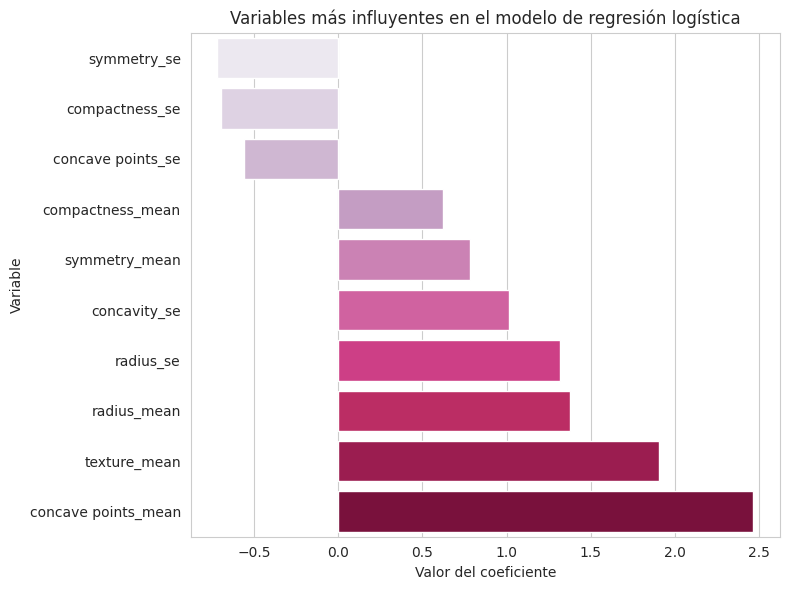

In [41]:
# ordenar para mejor visualización
top_variables = top_variables.sort_values(by="coeficiente")


fig, ax = plt.subplots(figsize=(8,6))

sns.barplot(
    data=top_variables,
    x="coeficiente",
    y="variable",
    palette="PuRd",
    hue="variable",
    ax=ax
)

ax.set_title("Variables más influyentes en el modelo de regresión logística")
ax.set_xlabel("Valor del coeficiente")
ax.set_ylabel("Variable")

plt.tight_layout()

display(fig)

plt.close()

9. Imprime el dataframe de resultados.
* Dibuja la matriz de confusión del mejor modelo. ¿Qué significa cada valor en ella?
* Dibuja la curva ROC del mismo modelo y describe lo que indica sobre su capacidad para distinguir entre clases.

In [42]:
# mostrar resultados finales de los modelos

display("Comparación final de modelos")
display(resultados_modelos)

'Comparación final de modelos'

,modelo,accuracy,precision,recall
0,Correlation_Clean,0.877193,0.888889,0.761905
1,Standard_PCA,0.973684,1.000000,0.928571
2,Correlation_Yeo,0.982456,1.000000,0.952381


In [43]:
# identificar el mejor modelo según recall y accuracy

mejor_modelo_nombre = resultados_modelos.sort_values(
    by=["recall", "accuracy"],
    ascending=False
).iloc[0]["modelo"]

display("Mejor modelo encontrado:")
display(mejor_modelo_nombre)

'Mejor modelo encontrado:'

'Correlation_Yeo'

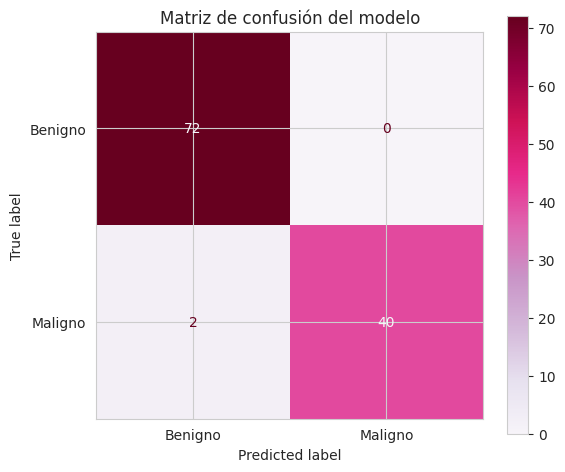

In [44]:

# generar predicciones del mejor modelo
predicciones_final = pipeline_yeo.predict(X_test)


# calcular matriz de confusión
matriz_confusion = confusion_matrix(y_test, predicciones_final)


# graficar matriz de confusión
fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=["Benigno", "Maligno"]
)

disp.plot(ax=ax, cmap="PuRd")

ax.set_title("Matriz de confusión del modelo")

plt.tight_layout()

display(fig)

plt.close()

### Interpretación de la matriz de confusión

La matriz de confusión permite analizar con mayor detalle el desempeño del modelo de clasificación.

Cada celda representa el número de observaciones clasificadas en cada combinación de clases reales y predichas.

- **True Negatives (TN)**: tumores benignos correctamente clasificados como benignos.
- **False Positives (FP)**: tumores benignos clasificados incorrectamente como malignos.
- **False Negatives (FN)**: tumores malignos clasificados incorrectamente como benignos.
- **True Positives (TP)**: tumores malignos correctamente clasificados como malignos.

En problemas médicos, los falsos negativos son especialmente críticos, ya que representan casos malignos que el modelo no logra detectar.

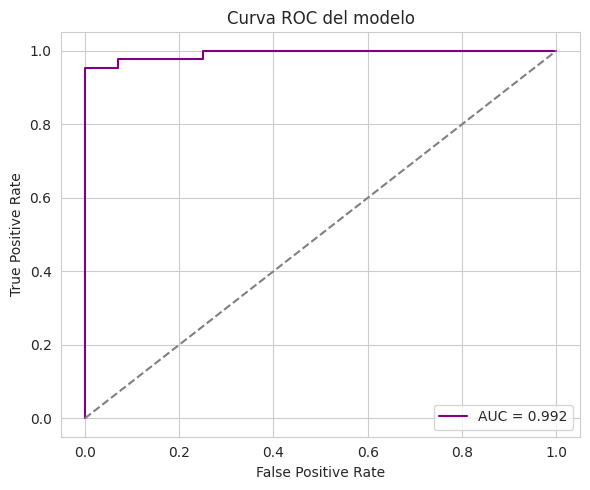

In [45]:
# obtener probabilidades del modelo
probabilidades = pipeline_yeo.predict_proba(X_test)[:,1]


# calcular ROC
fpr, tpr, thresholds = roc_curve(y_test, probabilidades)

roc_auc = auc(fpr, tpr)


# graficar ROC
fig, ax = plt.subplots(figsize=(6,5))

ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color="purple")
ax.plot([0,1], [0,1], linestyle="--", color="gray")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curva ROC del modelo")
ax.legend()

plt.tight_layout()

display(fig)

plt.close()

### Interpretación de la curva ROC

La curva ROC muestra la capacidad del modelo para distinguir entre tumores benignos y malignos a diferentes umbrales de clasificación.

Un modelo con buen desempeño presenta una curva que se aproxima a la esquina superior izquierda del gráfico, lo que indica una alta tasa de verdaderos positivos y una baja tasa de falsos positivos.

El área bajo la curva (AUC) resume esta capacidad en un solo valor. Un AUC cercano a 1 indica una excelente capacidad de discriminación entre clases, mientras que un valor cercano a 0.5 representaría un modelo sin capacidad predictiva.

En este caso, el valor del AUC indica que el modelo tiene una muy buena capacidad para diferenciar entre tumores benignos y malignos.

10. Grafica la distribución de las probabilidades predichas por clase utilizando histogramas superpuestos, diferenciando la clase Benigno (B) y la clase Maligno (M) con colores.
* ¿Cuál es el umbral (*threshold*) por defecto que utiliza scikit-learn para convertir probabilidades en predicciones binarias?
* En un modelo de diagnóstico médico, ¿cuál consideras que es la métrica más importante?
* ¿Cómo cambiarías (disminuir / aumentar) el *threshold*? ¿Por qué?

In [46]:
# obtener probabilidades predichas del modelo
probabilidades = pipeline_yeo.predict_proba(X_test)[:,1]


# crear dataframe para facilitar el análisis
prob_df = pd.DataFrame({
    "probabilidad_maligno": probabilidades,
    "diagnostico_real": y_test
})

display("Primeras probabilidades predichas")
display(prob_df.head())

'Primeras probabilidades predichas'

,probabilidad_maligno,diagnostico_real
421,0.139881,0
47,0.848888,1
292,0.001375,0
186,0.982806,1
414,0.772003,1


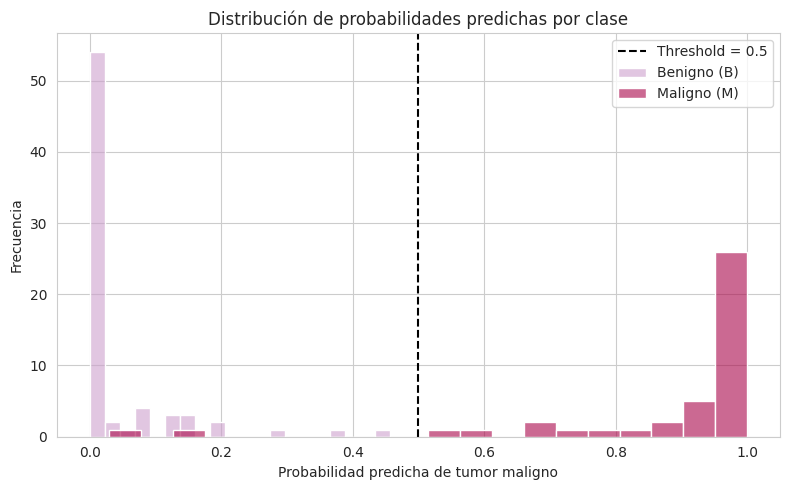

In [47]:
# separar probabilidades por clase real
prob_benigno = prob_df[prob_df["diagnostico_real"] == 0]["probabilidad_maligno"]
prob_maligno = prob_df[prob_df["diagnostico_real"] == 1]["probabilidad_maligno"]

# definir paleta PuRd
colores = sns.color_palette("PuRd", 5)

fig, ax = plt.subplots(figsize=(8,5))

# histograma benignos
sns.histplot(
    prob_benigno,
    bins=20,
    color=colores[1],   # tono claro
    label="Benigno (B)",
    alpha=0.6,
    ax=ax
)

# histograma malignos
sns.histplot(
    prob_maligno,
    bins=20,
    color=colores[4],   # tono más oscuro
    label="Maligno (M)",
    alpha=0.6,
    ax=ax
)

# línea del threshold
ax.axvline(0.5, color="black", linestyle="--", label="Threshold = 0.5")

ax.set_title("Distribución de probabilidades predichas por clase")
ax.set_xlabel("Probabilidad predicha de tumor maligno")
ax.set_ylabel("Frecuencia")

ax.legend()

plt.tight_layout()

display(fig)
plt.close()



### Threshold por defecto

El modelo de regresión logística de scikit-learn utiliza por defecto un umbral (*threshold*) de **0.5** para convertir probabilidades en predicciones binarias.

Esto significa que:

- Si la probabilidad predicha de la clase positiva (maligno) es **mayor o igual a 0.5**, el modelo clasifica el tumor como maligno.
- Si la probabilidad es **menor a 0.5**, el modelo clasifica el tumor como benigno.

### Métrica más importante en diagnóstico médico

En un problema de diagnóstico médico, la métrica más importante suele ser el **recall** (sensibilidad).

El recall mide la proporción de casos malignos reales que el modelo logra identificar correctamente.

Esto es especialmente relevante porque un **falso negativo** implica que un tumor maligno sea clasificado como benigno, lo cual puede retrasar el tratamiento del paciente y tener consecuencias graves.

### Ajuste del threshold

Para mejorar la detección de tumores malignos en un modelo de diagnóstico médico, sería recomendable **disminuir el threshold**.

Reducir el threshold hace que el modelo sea más sensible a la clase positiva (maligna), aumentando el número de casos clasificados como malignos.

Esto generalmente incrementa el **recall**, ya que se detectan más tumores malignos, aunque también puede aumentar el número de falsos positivo